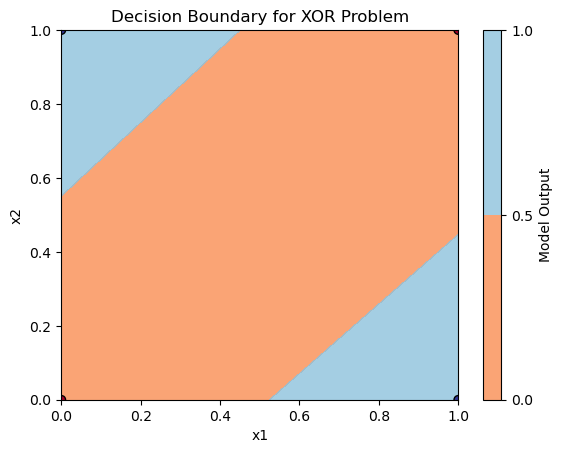

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# XOR inputs and outputs
inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # Input features
outputs = np.array([[0], [1], [1], [0]])  # XOR target outputs

# Initialize weights and biases randomly
np.random.seed(42)
input_weights = np.random.uniform(-1, 1, (2, 2))  # 2 inputs -> 2 hidden neurons
hidden_weights = np.random.uniform(-1, 1, (2, 1))  # 2 hidden neurons -> 1 output neuron
input_bias = np.random.uniform(-1, 1, (1, 2))  # Bias for 2 hidden neurons
hidden_bias = np.random.uniform(-1, 1, (1, 1))  # Bias for output neuron

# Learning rate
alpha = 0.1
epochs = 10000

# Training process
for epoch in range(epochs):
    # Forward Propagation
    hidden_input = np.dot(inputs, input_weights) + input_bias
    hidden_output = sigmoid(hidden_input)
    final_input = np.dot(hidden_output, hidden_weights) + hidden_bias
    final_output = sigmoid(final_input)

    # Error
    error = outputs - final_output

    # Backward Propagation
    output_gradient = error * sigmoid_derivative(final_output)
    hidden_weights_adjustment = np.dot(hidden_output.T, output_gradient)
    hidden_bias_adjustment = np.sum(output_gradient, axis=0, keepdims=True)

    hidden_error = np.dot(output_gradient, hidden_weights.T)
    hidden_gradient = hidden_error * sigmoid_derivative(hidden_output)
    input_weights_adjustment = np.dot(inputs.T, hidden_gradient)
    input_bias_adjustment = np.sum(hidden_gradient, axis=0, keepdims=True)

    # Update Weights and Biases
    hidden_weights += alpha * hidden_weights_adjustment
    hidden_bias += alpha * hidden_bias_adjustment
    input_weights += alpha * input_weights_adjustment
    input_bias += alpha * input_bias_adjustment

# Visualizing Decision Boundary
def plot_decision_boundary():
    # Create a grid of points
    x1_range = np.linspace(0, 1, 100)
    x2_range = np.linspace(0, 1, 100)
    xx, yy = np.meshgrid(x1_range, x2_range)
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Forward propagate the grid points through the trained MLP
    hidden_input = np.dot(grid_points, input_weights) + input_bias
    hidden_output = sigmoid(hidden_input)
    final_input = np.dot(hidden_output, hidden_weights) + hidden_bias
    predictions = sigmoid(final_input).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, predictions, levels=[0, 0.5, 1], cmap="RdYlBu", alpha=0.8)
    plt.colorbar(label="Model Output")

    # Overlay the XOR points
    plt.scatter(inputs[:, 0], inputs[:, 1], c=outputs.ravel(), cmap="RdYlBu", edgecolors="black")
    plt.title("Decision Boundary for XOR Problem")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary()
